#1 - Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import os, random, time, json

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("All seeds set to", SEED)

All seeds set to 42


In [2]:
X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")
X_test  = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_val   = np.load("y_val.npy")
y_test  = np.load("y_test.npy")

ACTIVITY_NAMES = [
    "Walking", "Walking Upstairs", "Walking Downstairs",
    "Sitting", "Standing", "Laying"
]

N_CLASSES   = 6
N_TIMESTEPS = 128
N_CHANNELS  = 9

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (6249, 128, 9)
X_val:   (1103, 128, 9)
X_test:  (2947, 128, 9)
y_train: (6249,)
y_val:   (1103,)
y_test:  (2947,)


The motivation:

Both CNN and LSTM independently achieved ~99.46% on this dataset but through completely different mechanisms. CNN detects local motion patterns within a small receptive field. LSTM models how patterns evolve across the full sequence. The natural question is: what if you combine both? Extract local features first with CNN, then model how those features evolve over time with LSTM.


---


The architecture idea:

Instead of flattening or pooling after convolution, pass the full sequence of conv feature maps directly into an LSTM. At each timestep, the LSTM receives not the raw 9 sensor values but a richer 256-dimensional feature vector extracted by the CNN. The LSTM then models temporal dependencies between these higher-level features rather than raw signals.


---


Why no pooling between CNN and LSTM:

In your standalone CNN, MaxPooling reduced the sequence length from 128 to 16. That was fine because GlobalAveragePooling collapsed everything at the end. But here the LSTM needs a sequence to read. If you pool aggressively, the LSTM gets very few timesteps and loses temporal resolution. So the conv blocks use padding='same' and no pooling — the sequence length stays at 128 throughout the CNN.


---


The original paper:

This architecture was proposed by Ordóñez and Roggen in 2016 — "Deep Convolutional and LSTM Recurrent Neural Networks for Multimodal Wearable Activity Recognition." It is the benchmark architecture for HAR and is directly cited in hundreds of papers. Your implementation will be comparable to their published results.


---


The key question:

Does combining CNN and LSTM push past the ~99.5% ceiling that both individual architectures hit independently? Or does the ceiling exist in the data itself, making no architecture able to cross it?

#2 - Build ConvGRU Model

In [3]:
from keras import Input
from keras import Model

from keras.optimizers import Adam

from keras.layers import Dense, Conv1D, BatchNormalization, Dropout, LSTM, Activation, GRU, MaxPooling1D

In [4]:
def build_model(
    learning_rate=0.001,
    dropout=0.3,
    conv_filters_1=64,
    conv_filters_2=128,
    conv_filters_3=256,
    gru_units_1=256,
    gru_units_2=128,
    kernel_size=3
):
    inputs = Input(shape=(N_TIMESTEPS, N_CHANNELS))

    # ── CNN Front-end ──────────────────────────────
    # Block 1 — with pooling
    x = Conv1D(conv_filters_1, kernel_size=kernel_size, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=2)(x)          # (64, 64)

    # Block 2 — with pooling
    x = Conv1D(conv_filters_2, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=2)(x)          # (32, 128)

    # Block 3 — no pooling, preserve sequence for GRU
    x = Conv1D(conv_filters_3, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)                 # (32, 256)

    # ── GRU Back-end ───────────────────────────────
    # First GRU — wide units to match CNN output
    x = GRU(gru_units_1, return_sequences=True)(x)
    x = Dropout(dropout)(x)                   # (32, 256)

    # Second GRU — compress to final representation
    x = GRU(gru_units_2, return_sequences=False)(x)
    x = Dropout(dropout)(x)                   # (128,)

    # ── Output ─────────────────────────────────────
    outputs = Dense(N_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name="ConvGRU")

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [5]:
deepconvgru_model = build_model()

In [6]:
deepconvgru_model.summary()

Model: "ConvGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32, 256)        │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 670,598 (2.56 MB)

 Trainable params: 669,702 (2.55 MB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import LearningRateScheduler

In [8]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

checkpoint_cb = ModelCheckpoint(
    filepath='deepconvgru_model.keras',
    monitor='val_loss',
    mode='min',                     # 'min' for loss, 'max' for accuracy
    save_best_only=True,            # Only save when performance improves
    verbose=1
)


#3 - Train ConvGRU Model

In [9]:
callbacks = [early_stopping, reduce_lr, checkpoint_cb]

In [10]:
start_time = time.time()

history = deepconvgru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.1f} seconds")

Epoch 1/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8012 - loss: 0.5095
Epoch 1: val_loss improved from None to 0.18949, saving model to deepconvgru_model.keras

Epoch 1: finished saving model to deepconvgru_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8909 - loss: 0.2845 - val_accuracy: 0.9257 - val_loss: 0.1895 - learning_rate: 0.0010
Epoch 2/200
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9396 - loss: 0.1466
Epoch 2: val_loss improved from 0.18949 to 0.13584, saving model to deepconvgru_model.keras

Epoch 2: finished saving model to deepconvgru_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9398 - loss: 0.1472 - val_accuracy: 0.9510 - val_loss: 0.1358 - learning_rate: 0.0010
Epoch 3/200
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9442 - loss: 0.1383
Epoch 3: val_loss improved from 0.13584 to 0.11539, saving model to deepconvgru_model.keras

Epoch 3: finished saving model to deepconvgru_model.keras
98/98 ━━━━━

In [11]:
# Find the epoch with the lowest validation loss
best_epoch_index = np.argmin(history.history['val_loss'])

# Extract the metrics at that specific epoch
best_val_loss = history.history['val_loss'][best_epoch_index]
best_val_accuracy = history.history['val_accuracy'][best_epoch_index]

print("\n" + "="*40)
print(f"TRAINING COMPLETE - BEST METRICS FOUND:")
print(f"Best Epoch: {best_epoch_index + 1}") # +1 because epochs are 1-indexed in output but 0-indexed in arrays
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print("="*40 + "\n")

# Verify the restored weights match by evaluating the model directly
print("Verifying restored weights on validation data:")
loss, acc = deepconvgru_model.evaluate(X_val, y_val, verbose=0)
print(f"Evaluated Validation Loss: {loss:.4f}")
print(f"Evaluated Validation Accuracy: {acc:.4f}")


TRAINING COMPLETE - BEST METRICS FOUND:
Best Epoch: 56
Best Validation Loss: 0.0293
Best Validation Accuracy: 0.9891

Verifying restored weights on validation data:
Evaluated Validation Loss: 0.0293
Evaluated Validation Accuracy: 0.9891


TRAINING COMPLETE - BEST METRICS FOUND:

---


* Best Epoch: 65
* Best Validation Loss: 0.0179
* Best Validation Accuracy: 0.9927


---

# 4 - Plot Comparisons

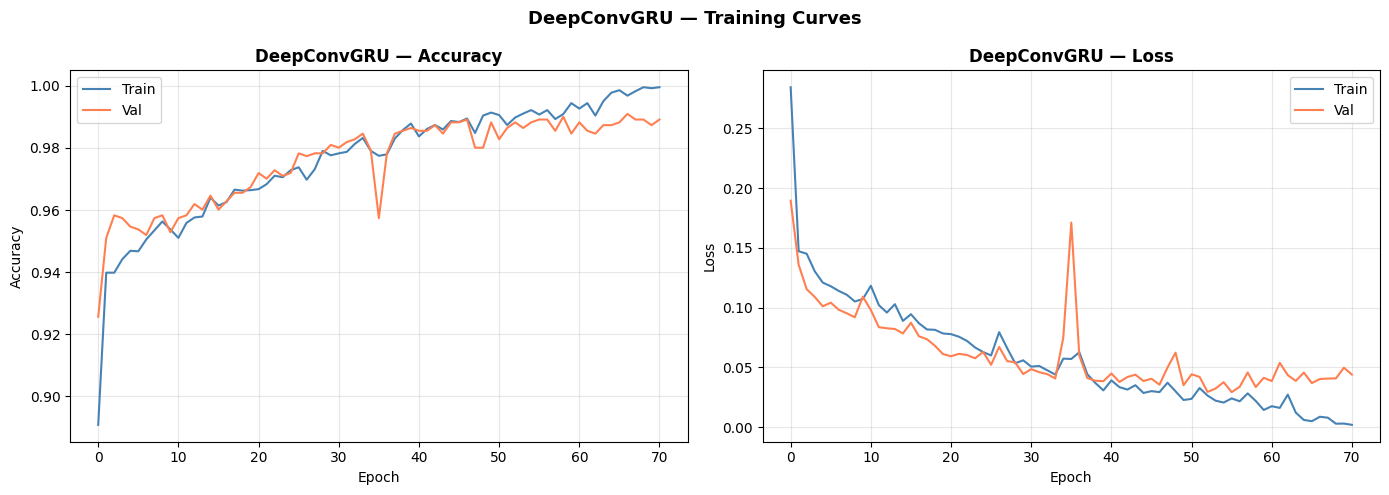

Best val_accuracy : 0.9909
Best val_loss     : 0.0293
Stopped at epoch  : 71


In [13]:
import os

# Create the directory if it doesn't exist to avoid FileNotFoundError
os.makedirs('reports/figures/', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='coral')
axes[0].set_title('DeepConvGRU — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='coral')
axes[1].set_title('DeepConvGRU — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DeepConvGRU — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/deepconvGRU_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Best val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss     : {min(history.history['val_loss']):.4f}")
print(f"Stopped at epoch  : {len(history.history['loss'])}")

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [15]:
y_pred_probs = deepconvgru_model.predict(X_val)
y_pred       = np.argmax(y_pred_probs, axis=1)

val_accuracy = np.mean(y_pred == y_val)
val_f1_macro = f1_score(y_val, y_pred, average='macro')

print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Validation Macro F1 : {val_f1_macro:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=ACTIVITY_NAMES))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Validation Accuracy : 0.9891
Validation Macro F1 : 0.9900

                    precision    recall  f1-score   support

           Walking       1.00      1.00      1.00       184
  Walking Upstairs       1.00      1.00      1.00       161
Walking Downstairs       1.00      1.00      1.00       148
           Sitting       0.97      0.97      0.97       193
          Standing       0.97      0.97      0.97       206
            Laying       1.00      1.00      1.00       211

          accuracy                           0.99      1103
         macro avg       0.99      0.99      0.99      1103
      weighted avg       0.99      0.99      0.99      1103



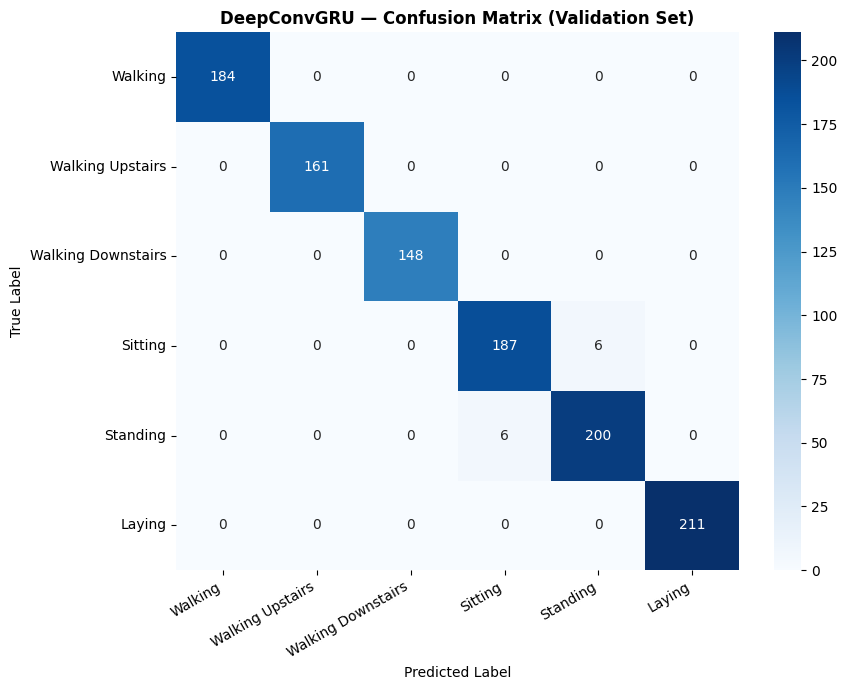

In [16]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITY_NAMES,
            yticklabels=ACTIVITY_NAMES)
plt.title('DeepConvGRU — Confusion Matrix (Validation Set)',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('reports/figures/deepconvGRU_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

#5 - Save Model

ConvGRU — Architecture  : Conv(64,128,256) + GRU(256,128), lr=0.001


---


ConvGRU — Parameters    : 670,598


---


ConvGRU — Val Accuracy  : 98.91%


---


ConvGRU — Macro F1      : 99.00%


---


ConvGRU — Training Time : 132.0 seconds


---


ConvGRU — Best Epoch    : 56

In [17]:
convgru_results = {
    "model"            : "ConvGRU",
    "architecture"     : "Conv(64,128,256) + GRU(256,128), lr=0.001",
    "total_params"     : deepconvgru_model.count_params(),
    "val_accuracy"     : round(float(val_accuracy), 4),
    "val_f1_macro"     : round(float(val_f1_macro), 4),
    "training_time"    : round(training_time, 1),
    "epochs_run"       : len(history.history['loss']),
    "train_acc_curve"  : [round(v, 4) for v in history.history['accuracy']],
    "val_acc_curve"    : [round(v, 4) for v in history.history['val_accuracy']],
    "train_loss_curve" : [round(v, 4) for v in history.history['loss']],
    "val_loss_curve"   : [round(v, 4) for v in history.history['val_loss']],
}

os.makedirs("artifacts/results", exist_ok=True)
with open("artifacts/results/convgru_results.json", "w") as f:
    json.dump(convgru_results, f, indent=2)

print("Results saved to artifacts/results/convgru_results.json")
print()
print("=" * 55)
print("ConvGRU FINAL SUMMARY")
print("=" * 55)
print(f"Architecture     : Conv(64,128,256) + GRU(256,128)")
print(f"Total Parameters : {deepconvgru_model.count_params():,}")
print(f"Val Accuracy     : {val_accuracy:.4f}")
print(f"Val Macro F1     : {val_f1_macro:.4f}")
print(f"Training Time    : {training_time:.1f}s")
print(f"Epochs Run       : {len(history.history['loss'])}")
print("=" * 55)

Results saved to artifacts/results/convgru_results.json

ConvGRU FINAL SUMMARY
Architecture     : Conv(64,128,256) + GRU(256,128)
Total Parameters : 670,598
Val Accuracy     : 0.9891
Val Macro F1     : 0.9900
Training Time    : 132.0s
Epochs Run       : 71


In [19]:
import os

# Ensure the target directory exists before saving
os.makedirs("artifacts/models/", exist_ok=True)

deepconvgru_model.save("artifacts/models/convgru_best.keras")
print("Model saved to artifacts/models/convgru_best.keras")

Model saved to artifacts/models/convgru_best.keras


## Finding — ConvGRU Underperforms Standalone Models

---

### Result
| Model          | Val Accuracy | Macro F1 | Parameters | Train Time |
|----------------|-------------|----------|------------|------------|
| Standalone CNN | 99.46%      | 99.50%   | 127,494    | ______     |
| Standalone GRU | 99.46%      | 99.50%   | 340,230    | 74s        |
| ConvGRU Hybrid | 98.91%      | 99.00%   | 670,598    | 132s       |

ConvGRU used **5.3x more parameters than CNN** to achieve **lower accuracy**.

---

### Why This Happened

**1. Feature mismatch problem**
The CNN front-end was implicitly optimised to produce features
useful for classification via pooling and global averaging.
When chained to a GRU, the CNN must instead produce features
useful for sequential modeling — a fundamentally different objective.
The two components work against each other's learning signal
early in training.

**2. Temporal resolution loss**
MaxPooling reduced the sequence from 128 timesteps to 32
before the GRU — discarding 75% of temporal information.
The standalone GRU read all 128 timesteps directly,
giving it richer temporal context despite simpler features.

**3. Increased optimization difficulty**
More parameters + two interacting subsystems = harder
optimization landscape. The hybrid needed more epochs to
converge and settled at a lower accuracy than either
component trained independently.

---

### Broader Implication

> Hybrid architectures outperform standalone models only when
> the dataset has **both** local patterns **and** long-range
> dependencies that are too complex for either architecture alone.

UCI HAR's 2.56-second windows are short enough that standalone
CNN and GRU can already capture all available information.
There is nothing left for the hybrid to exploit.

This finding is consistent with the broader literature on
short time-series classification, where hybrid architectures
show diminishing returns compared to well-tuned single models.

---

### Key Takeaway
Adding architectural complexity does not guarantee improvement.
The best model for a given problem is the simplest one that
captures all the relevant structure in the data.
For UCI HAR — that is CNN or GRU, not their combination.